In [1]:
import pandas as pd

train_df = pd.read_parquet('../dataset/train-00000-of-00001.parquet')
val_df   = pd.read_parquet('../dataset/validation-00000-of-00001.parquet')

print(f"Train rows      : {len(train_df)}")
print(f"Validation rows : {len(val_df)}")

Train rows      : 7000
Validation rows : 1034


In [2]:
# What columns do we have?
print("=== COLUMNS ===")
for col in train_df.columns:
    sample = train_df[col].iloc[0]
    print(f"  {col:30s}  type={type(sample).__name__}")

# Full first row, one field at a time
print("\n=== FIRST ROW ===")
for col in train_df.columns:
    val = train_df[col].iloc[0]
    print(f"\n[{col}]")
    print(val)

=== COLUMNS ===
  db_id                           type=str
  query                           type=str
  question                        type=str
  query_toks                      type=ndarray
  query_toks_no_value             type=ndarray
  question_toks                   type=ndarray

=== FIRST ROW ===

[db_id]
department_management

[query]
SELECT count(*) FROM head WHERE age  >  56

[question]
How many heads of the departments are older than 56 ?

[query_toks]
['SELECT' 'count' '(' '*' ')' 'FROM' 'head' 'WHERE' 'age' '>' '56']

[query_toks_no_value]
['select' 'count' '(' '*' ')' 'from' 'head' 'where' 'age' '>' 'value']

[question_toks]
['How' 'many' 'heads' 'of' 'the' 'departments' 'are' 'older' 'than' '56'
 '?']


In [3]:
def show_examples(df, n=5):
    for i, row in df.head(n).iterrows():
        print(f"{'='*60}")
        print(f"  Example      : {i+1}")
        print(f"  Database     : {row['db_id']}")
        print(f"  Question     : {row['question']}")
        print(f"  SQL          : {row['query']}")

show_examples(train_df)

  Example      : 1
  Database     : department_management
  Question     : How many heads of the departments are older than 56 ?
  SQL          : SELECT count(*) FROM head WHERE age  >  56
  Example      : 2
  Database     : department_management
  Question     : List the name, born state and age of the heads of departments ordered by age.
  SQL          : SELECT name ,  born_state ,  age FROM head ORDER BY age
  Example      : 3
  Database     : department_management
  Question     : List the creation year, name and budget of each department.
  SQL          : SELECT creation ,  name ,  budget_in_billions FROM department
  Example      : 4
  Database     : department_management
  Question     : What are the maximum and minimum budget of the departments?
  SQL          : SELECT max(budget_in_billions) ,  min(budget_in_billions) FROM department
  Example      : 5
  Database     : department_management
  Question     : What is the average number of employees of the departments whose rank 

In [4]:
def derive_difficulty(toks):
    """
    Replicates the official Spider hardness rubric exactly as defined in Yu et al. 2018.
    Uses query_toks_no_value (lowercased token list).

    Components 1 : WHERE GROUP ORDER LIMIT JOIN OR LIKE HAVING
    Components 2 : EXCEPT UNION INTERSECT + nested (more than one SELECT)
    Others       : >1 agg, >1 select cols, >1 where conditions, >1 group by cols
    """
    t = [x.upper() for x in toks]

    comp1 = {'WHERE', 'GROUP', 'ORDER', 'LIMIT', 'JOIN', 'OR', 'LIKE', 'HAVING'}
    comp2 = {'EXCEPT', 'UNION', 'INTERSECT'}

    n_comp1 = sum(1 for kw in comp1 if kw in t)
    n_comp2 = sum(1 for kw in comp2 if kw in t)
    has_nested = t.count('SELECT') > 1   # subquery = nested SELECT

    # Count "Others" conditions
    others = 0
    # >1 aggregation
    agg_kws = {'COUNT', 'MAX', 'MIN', 'AVG', 'SUM'}
    if sum(1 for tok in t if tok in agg_kws) > 1:
        others += 1
    # >1 select columns: count commas before FROM as a proxy
    from_idx = t.index('FROM') if 'FROM' in t else len(t)
    select_cols = t[:from_idx].count(',') + 1
    if select_cols > 1:
        others += 1
    # >1 where conditions: count ANDs/ORs in WHERE clause
    if t.count('AND') + t.count('OR') > 1:
        others += 1
    # >1 group by columns
    if 'GROUP' in t:
        gb_idx = t.index('GROUP')
        gb_section = t[gb_idx:gb_idx + 10]
        if gb_section.count(',') > 0:
            others += 1

    has_comp2 = n_comp2 > 0 or has_nested

    # --- Official rules ---
    # Easy
    if n_comp1 <= 1 and others == 0 and not has_comp2:
        return 'easy'

    # Extra Hard (catch-all, evaluated before hard to avoid overlap)
    # Hard cases
    hard = (
        (others > 2 and n_comp1 <= 2 and not has_comp2) or
        (2 < n_comp1 <= 3 and others <= 2 and not has_comp2) or
        (n_comp1 <= 1 and others == 0 and n_comp2 == 1 and not has_nested)
    )

    # Medium
    medium = (
        (others <= 2 and n_comp1 <= 1 and not has_comp2) or
        (n_comp1 == 2 and others < 2 and not has_comp2)
    )

    if has_comp2 and not hard:
        return 'extra hard'
    if hard:
        return 'hard'
    if medium:
        return 'medium'
    return 'extra hard'   # everything else


train_df['difficulty'] = train_df['query_toks_no_value'].apply(derive_difficulty)
val_df['difficulty']   = val_df['query_toks_no_value'].apply(derive_difficulty)

print("Train difficulty breakdown:")
print(train_df['difficulty'].value_counts())
print(f"\nAs percentages:")
print((train_df['difficulty'].value_counts(normalize=True) * 100).round(1))

print("\nValidation difficulty breakdown:")
print(val_df['difficulty'].value_counts())

Train difficulty breakdown:
difficulty
medium        3058
easy          1641
extra hard    1520
hard           781
Name: count, dtype: int64

As percentages:
difficulty
medium        43.7
easy          23.4
extra hard    21.7
hard          11.2
Name: proportion, dtype: float64

Validation difficulty breakdown:
difficulty
medium        441
extra hard    250
easy          239
hard          104
Name: count, dtype: int64


In [5]:
for level in ['easy', 'medium', 'hard']:
    row = train_df[train_df['difficulty'] == level].iloc[0]
    print(f"\n{'='*60}")
    print(f"  Difficulty : {level.upper()}")
    print(f"  Database   : {row['db_id']}")
    print(f"  Question   : {row['question']}")
    print(f"  SQL        : {row['query']}")


  Difficulty : EASY
  Database   : department_management
  Question   : How many heads of the departments are older than 56 ?
  SQL        : SELECT count(*) FROM head WHERE age  >  56

  Difficulty : MEDIUM
  Database   : department_management
  Question   : List the name, born state and age of the heads of departments ordered by age.
  SQL        : SELECT name ,  born_state ,  age FROM head ORDER BY age

  Difficulty : HARD
  Database   : department_management
  Question   : In which year were most departments established?
  SQL        : SELECT creation FROM department GROUP BY creation ORDER BY count(*) DESC LIMIT 1


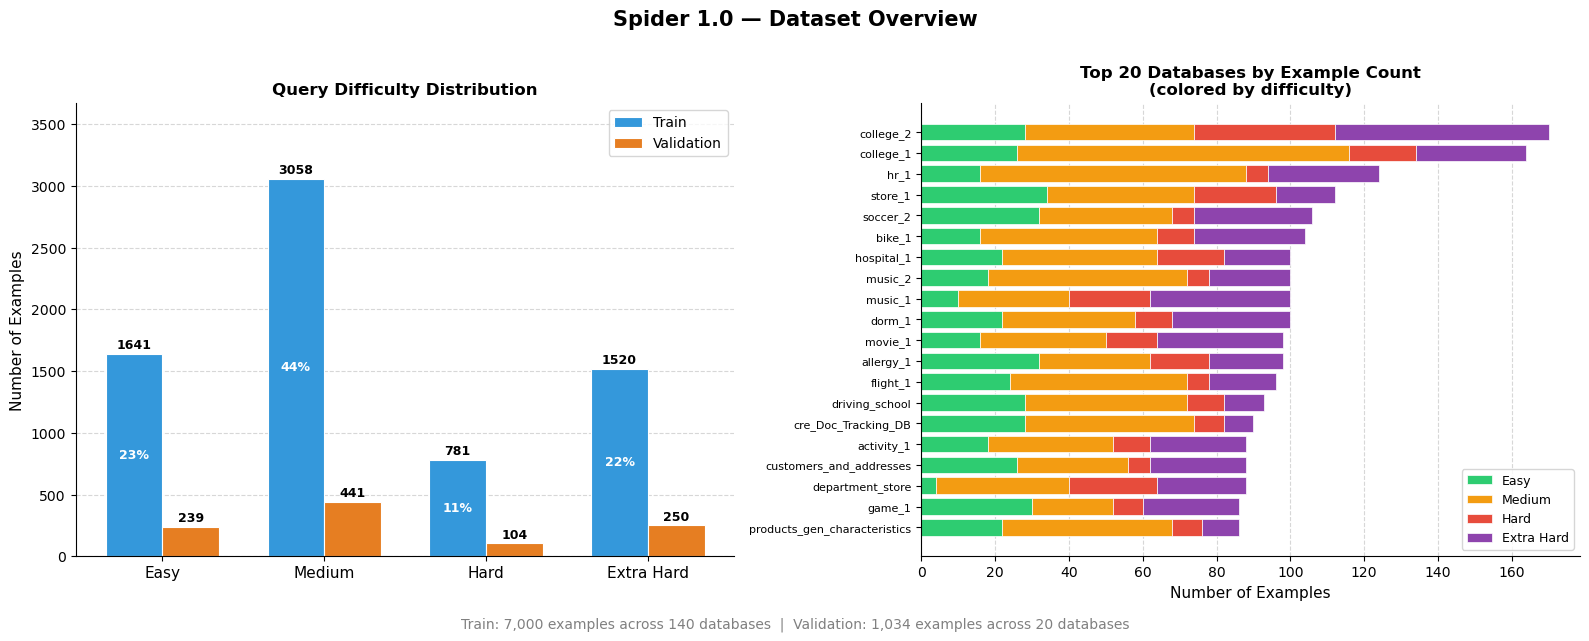

Saved → spider_eda_presentation.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Config ────────────────────────────────────────────────────────────────────
DIFFICULTY_ORDER  = ['easy', 'medium', 'hard', 'extra hard']
DIFFICULTY_COLORS = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
SPLIT_COLORS      = {'Train': '#3498db', 'Validation': '#e67e22'}
TOP_N_DBS         = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Spider 1.0 — Dataset Overview', fontsize=15, fontweight='bold', y=1.01)

# ── Chart 1: Difficulty distribution (Train vs Val) ───────────────────────────
ax1 = axes[0]

train_counts = train_df['difficulty'].value_counts().reindex(DIFFICULTY_ORDER, fill_value=0)
val_counts   = val_df['difficulty'].value_counts().reindex(DIFFICULTY_ORDER, fill_value=0)

x      = np.arange(len(DIFFICULTY_ORDER))
width  = 0.35

bars_train = ax1.bar(x - width/2, train_counts.values, width,
                     label='Train', color=SPLIT_COLORS['Train'],
                     edgecolor='white', linewidth=0.8)
bars_val   = ax1.bar(x + width/2, val_counts.values, width,
                     label='Validation', color=SPLIT_COLORS['Validation'],
                     edgecolor='white', linewidth=0.8)

# Value labels
for bar in bars_train:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 15,
             str(int(h)), ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars_val:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 15,
             str(int(h)), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Percentage annotations inside bars (train only)
total_train = train_counts.sum()
for i, v in enumerate(train_counts.values):
    ax1.text(x[i] - width/2, v / 2, f'{v/total_train*100:.0f}%',
             ha='center', va='center', fontsize=9, fontweight='bold',
             color='white')

ax1.set_xticks(x)
ax1.set_xticklabels([d.title() for d in DIFFICULTY_ORDER], fontsize=11)
ax1.set_ylabel('Number of Examples', fontsize=11)
ax1.set_title('Query Difficulty Distribution', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_ylim(0, train_counts.max() * 1.2)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)

# ── Chart 2: Database coverage (top N, colored by difficulty mix) ─────────────
ax2 = axes[1]

# Get top N databases by count
top_dbs = train_df['db_id'].value_counts().head(TOP_N_DBS)

# Stacked by difficulty
db_difficulty = (
    train_df[train_df['db_id'].isin(top_dbs.index)]
    .groupby(['db_id', 'difficulty'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=DIFFICULTY_ORDER, fill_value=0)
    .loc[top_dbs.index]   # keep top-N order
)

bottom = np.zeros(len(db_difficulty))
for i, (diff, color) in enumerate(zip(DIFFICULTY_ORDER, DIFFICULTY_COLORS)):
    vals = db_difficulty[diff].values
    ax2.barh(range(len(db_difficulty)), vals, left=bottom,
             color=color, edgecolor='white', linewidth=0.5,
             label=diff.title())
    bottom += vals

ax2.set_yticks(range(len(db_difficulty)))
ax2.set_yticklabels(db_difficulty.index, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('Number of Examples', fontsize=11)
ax2.set_title(f'Top {TOP_N_DBS} Databases by Example Count\n(colored by difficulty)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.xaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right']].set_visible(False)

# ── Total counts as subtitle ───────────────────────────────────────────────────
fig.text(0.5, -0.02,
         f'Train: {len(train_df):,} examples across {train_df["db_id"].nunique()} databases  |  '
         f'Validation: {len(val_df):,} examples across {val_df["db_id"].nunique()} databases',
         ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('spider_eda_presentation.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → spider_eda_presentation.png")

### Fetch the database schema

In [13]:
import urllib.request

url = "https://huggingface.co/datasets/richardr1126/spider-schema/resolve/main/spider_schema_rows_v2.json"
urllib.request.urlretrieve(url, "../dataset/spider_schema_rows_v2.json")
print("Done")

Done


In [15]:
import json

with open('../dataset/spider_schema_rows_v2.json') as f:
    schemas = json.load(f)

print(f"Number of databases: {len(schemas)}")
print(f"\nKeys per entry: {list(schemas[0].keys())}")
print(f"\n--- Example entry ---")
for k, v in schemas[0].items():
    print(f"\n[{k}]\n{v}")

Number of databases: 166

Keys per entry: ['Schema (values (type))', 'Primary Keys', 'Foreign Keys', 'db_id']

--- Example entry ---

[Schema (values (type))]
perpetrator : Perpetrator_ID (number) , People_ID (number) , Date (text) , Year (number) , Location (text) , Country (text) , Killed (number) , Injured (number) | people : People_ID (number) , Name (text) , Height (number) , Weight (number) , Home Town (text)

[Primary Keys]
perpetrator : Perpetrator_ID | people : People_ID

[Foreign Keys]
perpetrator : People_ID equals people : People_ID

[db_id]
perpetrator


### Check if the schema covers all tables from our dataset

In [19]:
# Check all db_ids in spider dataset are covered by the schema file
schema_dict = {s['db_id']: s for s in schemas}

train_dbs = set(train_df['db_id'].unique())
val_dbs   = set(val_df['db_id'].unique())
all_dbs   = train_dbs | val_dbs

missing = all_dbs - set(schema_dict.keys())

print(f"Databases in dataset  : {len(all_dbs)}")
print(f"Databases in schema   : {len(schema_dict)}")
print(f"Missing from schema   : {len(missing)}")
if missing:
    print(f"Missing db_ids: {missing}")
else:
    print("All databases covered!")

Databases in dataset  : 160
Databases in schema   : 166
Missing from schema   : 0
All databases covered!


### Prompt formatting and preview

In [20]:
def format_prompt(question, db_id, schema_dict):
    """
    Builds the prompt fed to Llama 3.1 8B for text-to-SQL inference.
    Format: schema + question → SQL
    """
    s = schema_dict[db_id]

    prompt = f"""You are an expert SQL assistant. Given a database schema and a question, generate the correct SQL query.
Only output the SQL query, no explanation, no markdown, no code blocks.

### Database Schema
{s['Schema (values (type))']}

### Primary Keys
{s['Primary Keys']}

### Foreign Keys
{s['Foreign Keys']}

### Question
{question}

### SQL
"""
    return prompt


# ── Preview on 3 examples across difficulty levels ───────────────────────────
for level in ['easy', 'medium', 'hard']:
    row = train_df[train_df['difficulty'] == level].iloc[0]
    prompt = format_prompt(row['question'], row['db_id'], schema_dict)

    print(f"{'='*65}")
    print(f"  DIFFICULTY : {level.upper()}")
    print(f"  DB         : {row['db_id']}")
    print(f"{'='*65}")
    print(prompt)
    print(f"  EXPECTED SQL: {row['query']}")
    print()

  DIFFICULTY : EASY
  DB         : department_management
You are an expert SQL assistant. Given a database schema and a question, generate the correct SQL query.
Only output the SQL query, no explanation, no markdown, no code blocks.

### Database Schema
department : Department_ID (number) , Name (text) , Creation (text) , Ranking (number) , Budget_in_Billions (number) , Num_Employees (number) | head : head_ID (number) , name (text) , born_state (text) , age (number) | management : department_ID (number) , head_ID (number) , temporary_acting (text)

### Primary Keys
department : Department_ID | head : head_ID | management : department_ID

### Foreign Keys
management : head_ID equals head : head_ID | management : department_ID equals department : Department_ID

### Question
How many heads of the departments are older than 56 ?

### SQL

  EXPECTED SQL: SELECT count(*) FROM head WHERE age  >  56

  DIFFICULTY : MEDIUM
  DB         : department_management
You are an expert SQL assistant. 